# mlr_pillow_selection.ipynb

In [1]:
import xarray as xr
import os 
import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from rasterio.enums import Resampling
from typing import List, Dict, Tuple, Optional
from datetime import datetime
import time
import importlib

In [2]:
sys.path.insert(1, '/home/rossamower/bin/scripts/')

In [3]:
import metadata as metadata
import plotting as plotting
import preprocessing as preprocessing
import lm_model as lm_model
import postprocessing as postprocessing

In [4]:
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(preprocessing)
importlib.reload(lm_model)
importlib.reload(postprocessing)

<module 'postprocessing' from '/home/rossamower/bin/scripts/postprocessing.py'>

# Inputs

In [5]:
aso_site_name = 'USCASJ'
water_year = 2026

# Functions

## load metadata

In [6]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snowmodel_dir = cfg["data_filepaths"]["snowmodel_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    mlrPred_dir = cfg["data_filepaths"]["mlrPred_dir"]
    if not os.path.exists(mlrPred_dir): os.makedirs(mlrPred_dir)
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir, uaswe_dir, shape_crs, cfg

## Load ASO

In [7]:
def load_aso_data(aso_spatial_fpath: str,
                  aso_tseries_fpath: str,
                  demBin_fpath: str,
                  shape_fpath: str,
                  shape_crs: str,
                 ):
    aso_spatial_ds = xr.open_dataset(aso_spatial_fpath,engine ='netcdf4')
    aso_demBin_ds = xr.open_dataset(demBin_fpath,engine ='netcdf4')
    aso_tseries_ds = xr.open_dataset(aso_tseries_fpath,engine ='netcdf4')
    shape_geog_gdf = gpd.read_file(shape_fpath)
    shape_proj_gdf = shape_geog_gdf.to_crs(shape_crs)

    return aso_spatial_ds, aso_demBin_ds, shape_proj_gdf, aso_tseries_ds

## Misc

In [8]:
def pad_zero(val_str):
    if len(val_str) ==1:
        return '0' + val_str
    else:
        return val_str

def dataset_to_list(ds: xr.Dataset) -> list:
    da_list = []
    for pil in ds.data_vars:
        da = ds[pil]
        da.name = pil
        da_list.append(da)
    return da_list

def snowmodel_swe_fpaths(base_dir,water_yrs,var):
    nc_lst = []
    for wy in water_yrs:
        nc_dir = f'{base_dir}wy_{wy}/netcdf/'
        for file in os.listdir(nc_dir):
            if var in file:
                nc_lst.append(nc_dir + file)
    return sorted(nc_lst)

def timing_vars(obs_data_test_ds: xr.Dataset):
    date_str = str(obs_data_test_ds.time.values[-1])[0:10]
    year_str = date_str[0:4]
    month_str = date_str[5:7]
    day_str = date_str[8:10]
    
    if int(month_str) >= 10:
        wy_str = str(int(year_str) +1)
    else:
        wy_str = year_str
    return year_str, month_str, day_str, wy_str

def get_default_settings():
    user_elevation_interval = -1
    model_num = 0   
    isMean = False
    isCombination = True
    prediction_mm_df = None
    prediction_acreFt_df = None
    prediction_pillow_df = None
    isCombination = True
    user_qa_level = 0
    QA_flag = user_qa_level + 1
    elev_band = user_elevation_interval
    return model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag

# Preprocessing

## Default Settings

In [9]:
model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag = get_default_settings()

## Load Metadata

In [10]:
# load metadata information.
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir,uaswe_dir,shape_crs,cfg = load_aso_metadata(aso_site_name)

# pillows to exclude from QA.
exclude_pillows = cfg['pillow_api']['exclude_pillows']
elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
start_wy = int(cfg["aso_years"]["start"])
end_wy = int(cfg["aso_years"]["end"])

In [11]:
exclude_pillows

['KUP']

## Load Input Data

In [12]:
# load spatial data.
aso_spatial_ds, dem_bin, shape_proj_gdf, aso_tseries_ds = load_aso_data(aso_spatial_fpath,
                                                                                aso_tseries_fpath,
                                                                                demBin_fpath,
                                                                                shape_fpath,
                                                                                shape_crs)

# obs training.
obs_data_train_ds = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
obs_data_train_lst = dataset_to_list(obs_data_train_ds)
# snowmodel 
sm_train_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_train_2017_2025_dowy.zarr', consolidated=False)
sm_test_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_test_2026.zarr', consolidated=False)

# testing raw.
obs_data_test_ds_raw = xr.load_dataset(f'{insitu_dir}raw/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# match times.
obs_data_test_ds_raw = obs_data_test_ds_raw.sel(time = sm_test_ds.time)
obs_data_test_lst_raw = dataset_to_list(obs_data_test_ds_raw)
# testing qa.
obs_data_test_ds = xr.load_dataset(f'{insitu_dir}processed/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# match times.
# obs_data_test_ds = obs_data_test_ds.sel(time = sm_test_ds.time)
obs_data_test_ds = obs_data_test_ds.where(obs_data_test_ds.time.isin(sm_test_ds.time.values),drop = True)
obs_data_test_lst = dataset_to_list(obs_data_test_ds)
# initial pillow list.
pillows = list(obs_data_test_ds.data_vars)
pillows = [i for i in pillows if i not in exclude_pillows]
# get timing variables.
year_str, month_str, day_str, wy_str = timing_vars(obs_data_test_ds)
# load UASWE data.
uaswe_acreFt_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_acreFt_wy{water_year}.csv')
uaswe_m_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_m_wy{water_year}.csv')
# load SNODAS data.
snodas_acreFt_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_acreFt_wy{water_year}.csv')
snodas_m_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_m_wy{water_year}.csv')
# load SnowModel data.
sm_acreFt_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_acreFt_wy{water_year}.csv')
sm_m_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_m_wy{water_year}.csv')
# convert date columns to datetime.
snodas_acreFt_df['Date'] = pd.to_datetime(snodas_acreFt_df['Date'])
snodas_m_df['Date'] = pd.to_datetime(snodas_m_df['Date'])
uaswe_acreFt_df['Date'] = pd.to_datetime(uaswe_acreFt_df['Date'])
uaswe_m_df['Date'] = pd.to_datetime(uaswe_m_df['Date'])
sm_acreFt_df['Date'] = pd.to_datetime(sm_acreFt_df['Date'])
sm_m_df['Date'] = pd.to_datetime(sm_m_df['Date'])

In [13]:
sm_test_ds

<xarray.Dataset> Size: 65kB
Dimensions:      (pil: 30, time: 107)
Coordinates:
  * pil          (pil) <U3 360B 'AGP' 'BCB' 'BGP' 'BSH' ... 'UBC' 'VLC' 'WWC'
  * time         (time) datetime64[ns] 856B 2025-10-01 2025-10-02 ... 2026-01-15
Data variables:
    swe_obs      (time, pil) float64 26kB dask.array<chunksize=(107, 30), meta=np.ndarray>
    swed_best    (time, pil) float32 13kB dask.array<chunksize=(107, 30), meta=np.ndarray>
    swed_second  (time, pil) float32 13kB dask.array<chunksize=(107, 30), meta=np.ndarray>
    swed_third   (time, pil) float32 13kB dask.array<chunksize=(107, 30), meta=np.ndarray>

## Load Output Data

In [14]:
seasonal_dirs = ["season","accum","melt"]
models = ["COMMON_MASK"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        prediction_acreFt_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        prediction_mm_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        prediction_pillows_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        prediction_mm_df['Date'] = pd.to_datetime(prediction_mm_df['Date'])
        prediction_acreFt_df['Date'] = pd.to_datetime(prediction_acreFt_df['Date'])
        prediction_pillows_df['Date'] = pd.to_datetime(prediction_pillows_df['Date'])
            
        mlr_tables.append(prediction_acreFt_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        count += 1 
        mlr_tables.append(prediction_mm_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        count += 1
        mlr_tables.append(prediction_pillows_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        count += 1

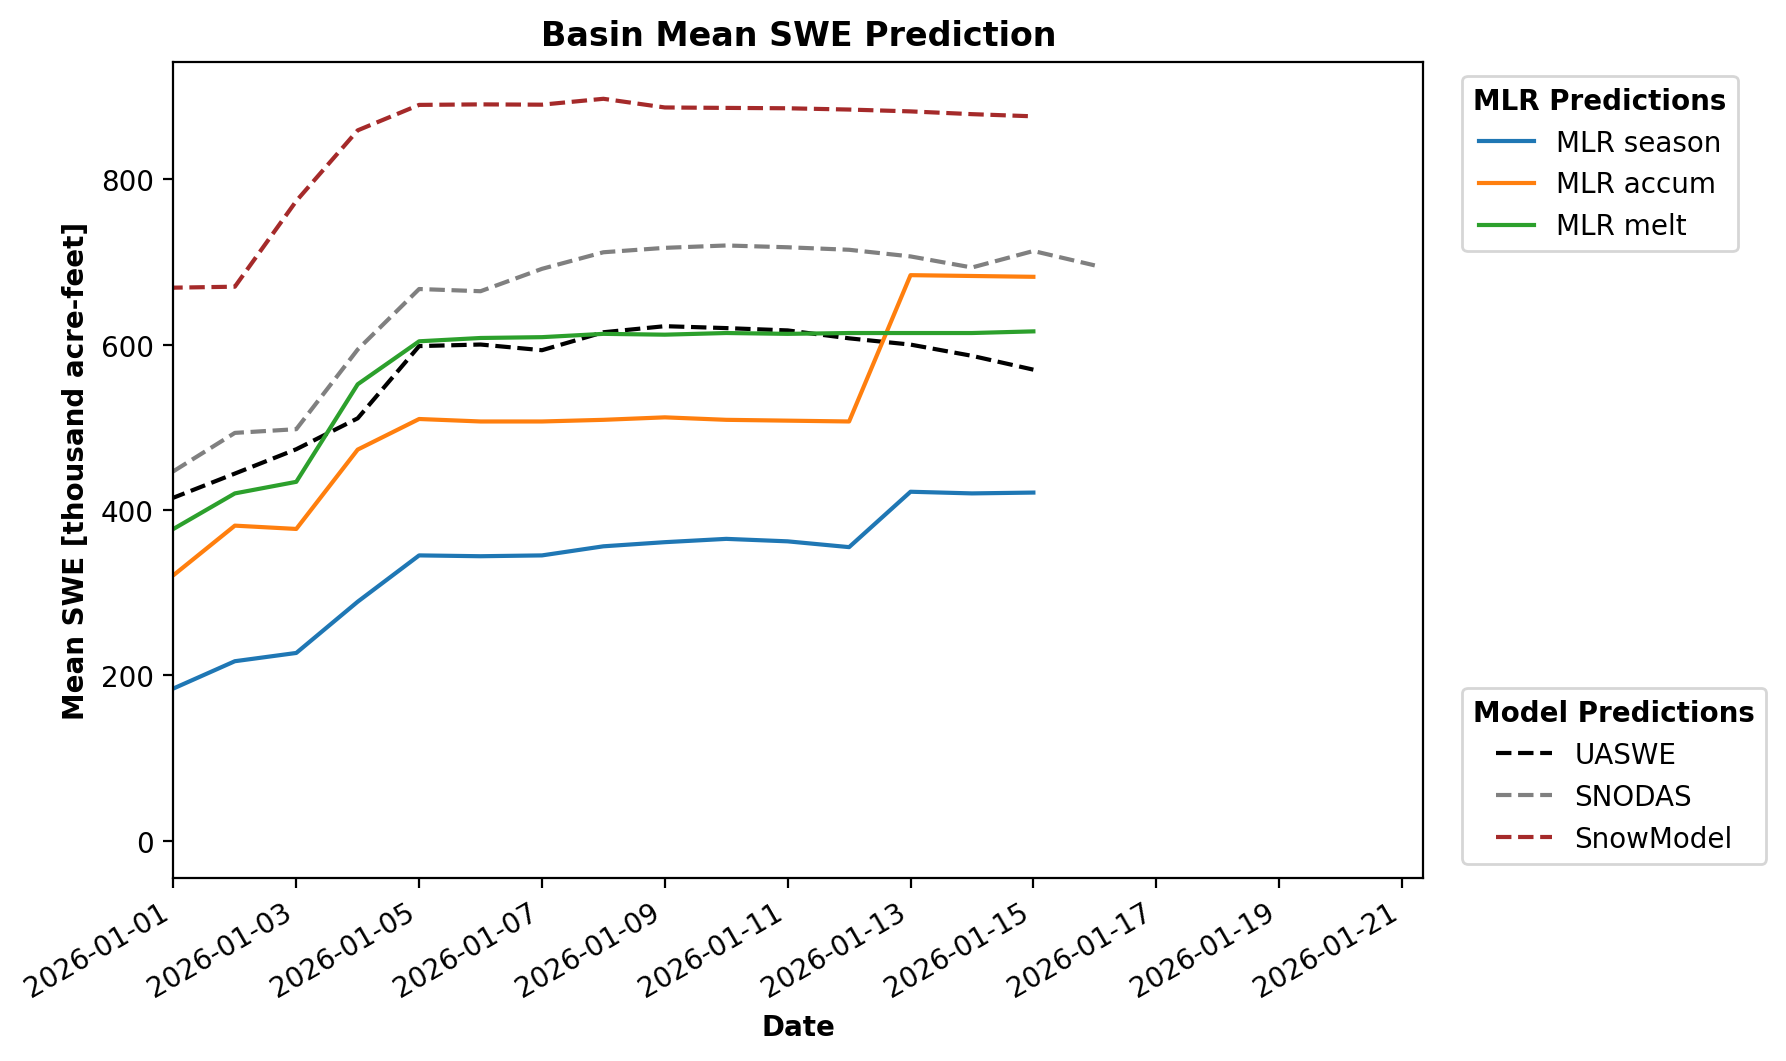

In [15]:
importlib.reload(plotting)
plotting.html_timeseries_plot(mlr_tables,
                                  mlr_identifiers,
                                  uaswe_acreFt_df,
                                  snodas_acreFt_df,
                                  sm_acreFt_df,
                                  aso_site_name,
                                  None,
                                  train_infer = 'predict NaNs',
                                  saveFIG = False,
    )

In [16]:
mlr_identifiers

{0: ['COMMON_MASK', 'season', 'acreFt'],
 1: ['COMMON_MASK', 'season', 'mm'],
 2: ['COMMON_MASK', 'season', 'pillows'],
 3: ['COMMON_MASK', 'accum', 'acreFt'],
 4: ['COMMON_MASK', 'accum', 'mm'],
 5: ['COMMON_MASK', 'accum', 'pillows'],
 6: ['COMMON_MASK', 'melt', 'acreFt'],
 7: ['COMMON_MASK', 'melt', 'mm'],
 8: ['COMMON_MASK', 'melt', 'pillows']}

In [17]:
mlr_tables[2].iloc[-90]

Date                   2025-12-02 00:00:00
Model Type                             MLR
Training Infer NaNs              drop NaNs
Prediction QA                            1
<7k                          PSR, SWM, TMR
7k-8k                             PSR, SWM
8k-9k                        CHM, KSP, SWM
9k-10k                       CHM, KSP, LLE
10k-11k                           KSP, LLE
11k-12k                 CHM, DAN, KSP, LLE
>12k                    CHM, DAN, KSP, LLE
Basin                        LLE, PSR, STL
Name: 122, dtype: object

In [18]:
mlr_tables[5].iloc[-1]

Date                       2026-01-15 00:00:00
Model Type                                 MLR
Training Infer NaNs               predict NaNs
Prediction QA                                1
<7k                                        PSR
7k-8k                            KSP, PSR, STL
8k-9k                       DAN, KSP, LLE, STL
9k-10k                           CHM, MHP, PSR
10k-11k                CHM, MHP, STR, SWM, TNY
11k-12k                CHM, LLE, STL, STR, TNY
>12k                             CHM, LLE, STL
Basin                            LLE, STL, SWM
Name: 211, dtype: object

In [19]:
mlr_tables[8].iloc[-30]

Date                   2026-01-01 00:00:00
Model Type                             MLR
Training Infer NaNs              drop NaNs
Prediction QA                            1
<7k                                    PSR
7k-8k                        SLK, STL, TMR
8k-9k                             KSP, TNY
9k-10k                            CHM, KSP
10k-11k                                TMR
11k-12k                                TMR
>12k                              DAN, KSP
Basin                                  PSR
Name: 182, dtype: object

In [20]:
uaswe_m_df

,Date,<7000,7000-8000,8000-9000,9000-10000,10000-11000,11000-12000,>12000,total
0,2025-10-01,0.000000e+00,0.000000,0.000000,1.572248e-08,0.000061,0.000435,0.001200,0.000049
1,2025-10-02,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000011,0.000169,0.000453,0.000018
2,2025-10-03,0.000000e+00,0.000000,0.000000,1.609504e-05,0.000705,0.001521,0.002009,0.000193
3,2025-10-04,2.452420e-06,0.000725,0.003173,4.938319e-03,0.006725,0.008880,0.009657,0.002433
4,2025-10-05,4.330528e-09,0.000066,0.000671,1.887129e-03,0.005040,0.008339,0.009538,0.001464
...,...,...,...,...,...,...,...,...,...
84,2026-01-11,3.052643e-02,0.186837,0.233898,3.042570e-01,0.431221,0.545984,0.589951,0.188442
85,2026-01-12,2.766531e-02,0.181348,0.230641,3.024509e-01,0.429912,0.543938,0.587401,0.185519
86,2026-01-13,2.489900e-02,0.175911,0.228056,3.017828e-01,0.430125,0.544283,0.587669,0.183205
87,2026-01-14,2.163032e-02,0.165624,0.221546,2.984466e-01,0.429073,0.544103,0.587652,0.179056


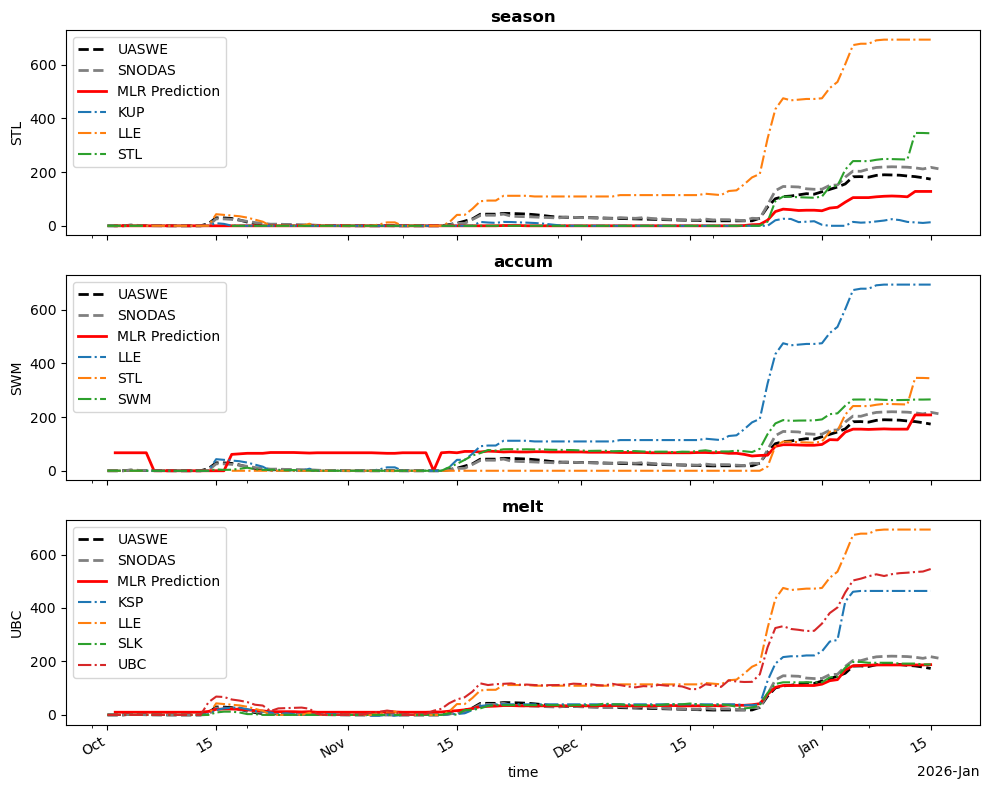

In [21]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(3,1,figsize=(10,8),sharex=True)
# season
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[1][mlr_tables[1]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[2].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[2][1],fontweight = 'bold')
# accum
ax[1].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[1].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[1],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[1],label=pil,linestyle = '-.')
ax[1].legend()
ax[1].set_title(mlr_identifiers[5][1],fontweight = 'bold')
# melt
ax[2].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[2].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[7][mlr_tables[7]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[2],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[8].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[2],label=pil,linestyle = '-.')
ax[2].legend()
ax[2].set_title(mlr_identifiers[8][1],fontweight = 'bold')
plt.tight_layout()
plt.show()

0 ['COMMON_MASK', 'season', 'acreFt']
1 ['COMMON_MASK', 'season', 'mm']
2 ['COMMON_MASK', 'season', 'pillows']
3 ['COMMON_MASK', 'accum', 'acreFt']
4 ['COMMON_MASK', 'accum', 'mm']
5 ['COMMON_MASK', 'accum', 'pillows']
6 ['COMMON_MASK', 'melt', 'acreFt']
7 ['COMMON_MASK', 'melt', 'mm']
8 ['COMMON_MASK', 'melt', 'pillows']
4 5


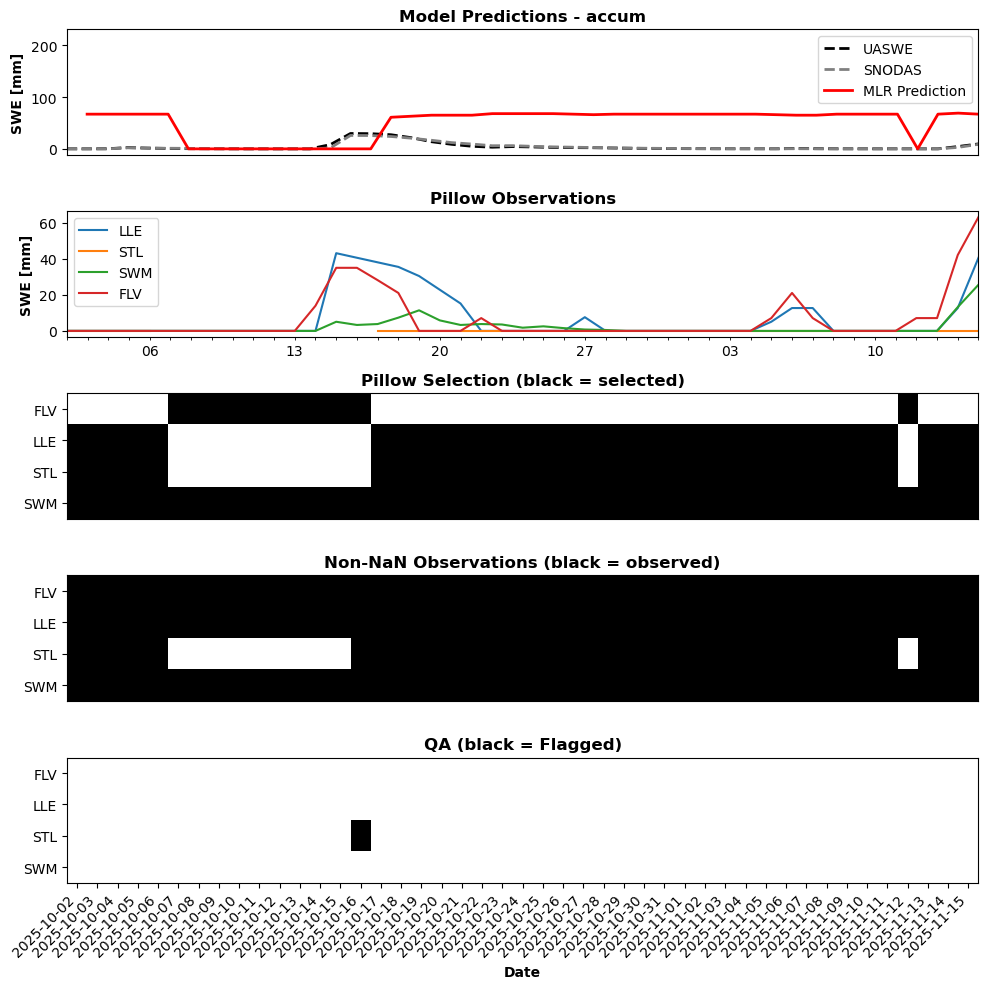

In [22]:
importlib.reload(plotting)
df_pred_slice, df_pil_slice, df_pil_explode, df_pil_mat,diff_arr,nan_arr,diff_mask = plotting.timeseries_pillow_selection(mlr_tables,
                                mlr_identifiers,
                                uaswe_m_df,
                                snodas_m_df,
                                obs_data_test_ds_raw,
                                obs_data_test_ds,
                                start_date = '2025-10-01',
                                end_date = '2025-11-15',
                                model_type = 'accum',
                                model_units = 'mm'
                                )

In [41]:
mlr_identifiers

{0: ['COMMON_MASK', 'season', 'acreFt'],
 1: ['COMMON_MASK', 'season', 'mm'],
 2: ['COMMON_MASK', 'season', 'pillows'],
 3: ['COMMON_MASK', 'accum', 'acreFt'],
 4: ['COMMON_MASK', 'accum', 'mm'],
 5: ['COMMON_MASK', 'accum', 'pillows'],
 6: ['COMMON_MASK', 'melt', 'acreFt'],
 7: ['COMMON_MASK', 'melt', 'mm'],
 8: ['COMMON_MASK', 'melt', 'pillows']}

In [59]:
df_pred_slice = mlr_tables[4][(mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs') &  \
              (mlr_tables[4]['Date'] < np.datetime64('2025-11-15'))]

In [60]:
df_pil_slice = mlr_tables[5][(mlr_tables[5]['Training Infer NaNs'] == 'predict NaNs') &  \
              (mlr_tables[5]['Date'] < np.datetime64('2025-11-15'))][['Date','Basin']]

Text(0.5, 1.0, 'clean pillows')

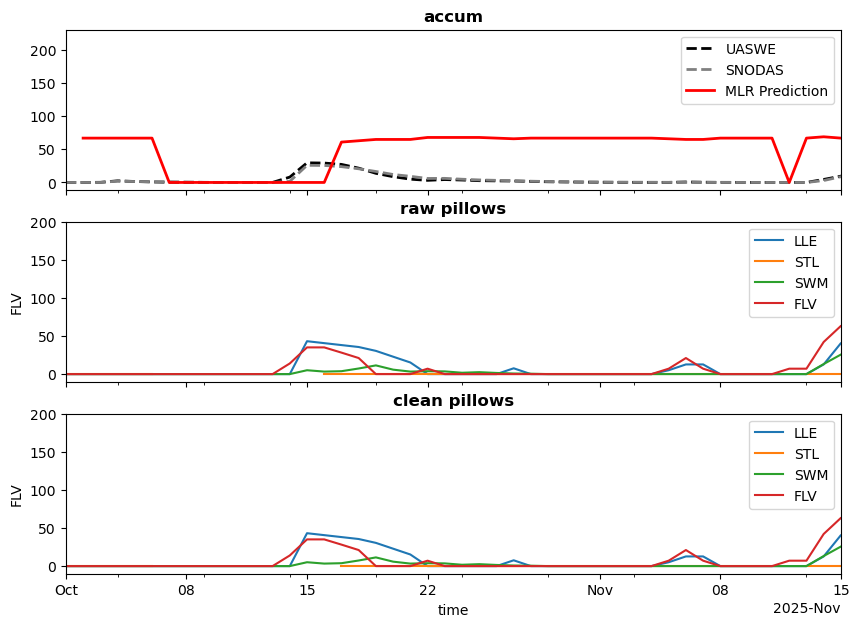

In [58]:
fig,ax = plt.subplots(3,1,figsize=(10,8),sharex=True)
# accum
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
# for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
#     obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[5][1],fontweight = 'bold')
ax[0].set_xlim(np.datetime64('2025-10-01'),np.datetime64('2025-11-15'))

obs_data_test_ds_raw['LLE'].plot(ax=ax[1],label='LLE',linestyle = '-')
obs_data_test_ds_raw['STL'].plot(ax=ax[1],label='STL',linestyle = '-')
obs_data_test_ds_raw['SWM'].plot(ax=ax[1],label='SWM',linestyle = '-')
obs_data_test_ds_raw['FLV'].plot(ax=ax[1],label='FLV',linestyle = '-')
ax[1].legend()
ax[1].set_ylim(-10,200)
ax[1].set_title('raw pillows',fontweight = 'bold')


obs_data_test_ds['LLE'].plot(ax=ax[2],label='LLE',linestyle = '-')
obs_data_test_ds['STL'].plot(ax=ax[2],label='STL',linestyle = '-')
obs_data_test_ds['SWM'].plot(ax=ax[2],label='SWM',linestyle = '-')
obs_data_test_ds['FLV'].plot(ax=ax[2],label='FLV',linestyle = '-')
ax[2].legend()
ax[2].set_ylim(-10,200)
ax[2].set_title('clean pillows',fontweight = 'bold')

In [67]:
df_pil_slice

,Date,Basin
1,2025-10-02,"LLE, STL, SWM"
3,2025-10-03,"LLE, STL, SWM"
5,2025-10-04,"LLE, STL, SWM"
7,2025-10-05,"LLE, STL, SWM"
9,2025-10-06,"LLE, STL, SWM"
11,2025-10-07,"FLV, SWM"
13,2025-10-08,"FLV, SWM"
15,2025-10-09,"FLV, SWM"
17,2025-10-10,"FLV, SWM"
19,2025-10-11,"FLV, SWM"


In [98]:
obs_data_test_ds_raw.where(obs_data_test_ds_raw.time < np.datetime64('2025-10-01'))

<xarray.Dataset> Size: 25kB
Dimensions:  (time: 102)
Coordinates:
  * time     (time) datetime64[ns] 816B 2025-10-01 2025-10-02 ... 2026-01-10
Data variables: (12/30)
    AGP      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    BCB      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    BGP      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    BSH      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    CHM      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    DAN      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    ...       ...
    TMR      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    TNY      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    TUM      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    UBC      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    VLC      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan
    WWC      (time) float64 816B nan nan nan nan nan nan ... nan nan nan nan nan

In [101]:
raw_df = obs_data_test_ds_raw.where(obs_data_test_ds_raw.time > np.datetime64('2025-10-01'),drop = True) \
                    .where(obs_data_test_ds_raw.time < np.datetime64('2025-11-15'),drop = True) \
                   [['LLE','STL','SWM','FLV']].to_dataframe()

test_df = obs_data_test_ds.where(obs_data_test_ds.time > np.datetime64('2025-10-01'),drop = True) \
                    .where(obs_data_test_ds.time < np.datetime64('2025-11-15'),drop = True) \
                   [['LLE','STL','SWM','FLV']].to_dataframe()

In [107]:
diff_mask = ~(
    (raw_df == test_df) |
    (raw_df.isna() & test_df.isna())
)
diff_mask

nan_mask = ~raw_df.isna()
nan_mask

,LLE,STL,SWM,FLV
time,,,,
2025-10-02,True,True,True,True
2025-10-03,True,True,True,True
2025-10-04,True,True,True,True
2025-10-05,True,True,True,True
2025-10-06,True,True,True,True
2025-10-07,True,False,True,True
2025-10-08,True,False,True,True
2025-10-09,True,False,True,True
2025-10-10,True,False,True,True


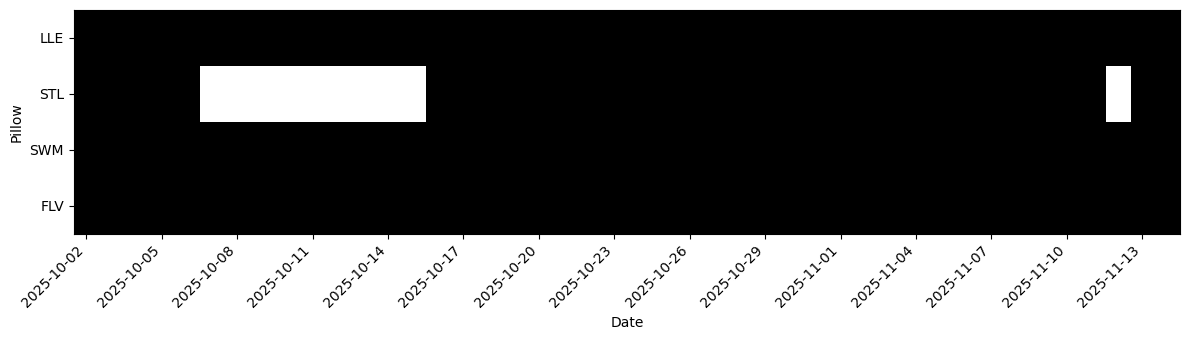

In [109]:
df = nan_mask.copy()

# Ensure datetime + sorted
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Convert to numeric for plotting:
#   True -> 1, False -> 0, NaN -> np.nan (so it can be a separate color if you want)
arr = df.astype("float").to_numpy().T   # transpose so pillows are rows, time is cols

fig, ax = plt.subplots(figsize=(12, 3.5))

im = ax.imshow(
    arr,
    aspect="auto",
    interpolation="nearest",
    cmap = 'binary'
)

ax.set_xlabel("Date")
ax.set_ylabel("Pillow")

# Y ticks = pillows
ax.set_yticks(np.arange(df.shape[1]))
ax.set_yticklabels(df.columns)
# X ticks = dates (downsample if many)
step = max(1, len(df.index) // 12)  # ~12 ticks
xt = np.arange(0, len(df.index), step)
ax.set_xticks(xt)
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in df.index[xt]], rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [1]:
# Ensure datetime
df = df_pil_slice.copy()
df["Date"] = pd.to_datetime(df["Date"])

# Split basin strings into lists
df["Pillow"] = df["Basin"].str.split(r"\s*,\s*")

# Explode to long format
df_long = df.explode("Pillow")[["Date", "Pillow"]]
# Create binary presence matrix
mat = (
    df_long
    .assign(value=1)
    .pivot(index="Pillow", columns="Date", values="value")
    .fillna(0)
    .sort_index()
)
fig,ax = plt.subplots(2,1,figsize=(10,8),sharex=False)
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
# for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
#     obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[5][1],fontweight = 'bold')
ax[0].set_xlim(np.datetime64('2025-10-01'),np.datetime64('2025-11-14'))
ax[0].set_xticks([])
ax[0].set_xlabel('')

im = ax[1].imshow(
    mat.values,
    aspect="auto",
    interpolation="nearest",
    cmap = 'binary',
)

# Axis labels
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Pillow")

# Ticks
ax[1].set_yticks(range(len(mat.index)))
ax[1].set_yticklabels(mat.index)

ax[1].set_xticks(range(len(mat.columns)))
ax[1].set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in mat.columns],
    rotation=45,
    ha="right"
)

ax[1].set_title('Pillow Selection (black = selected)',fontweight = 'bold')
plt.tight_layout()
plt.show()

NameError: name 'df_pil_slice' is not defined

In [82]:
[d.strftime("%Y-%m-%d") for d in mat.columns]

['2025-10-02',
 '2025-10-03',
 '2025-10-04',
 '2025-10-05',
 '2025-10-06',
 '2025-10-07',
 '2025-10-08',
 '2025-10-09',
 '2025-10-10',
 '2025-10-11',
 '2025-10-12',
 '2025-10-13',
 '2025-10-14',
 '2025-10-15',
 '2025-10-16',
 '2025-10-17',
 '2025-10-18',
 '2025-10-19',
 '2025-10-20',
 '2025-10-21',
 '2025-10-22',
 '2025-10-23',
 '2025-10-24',
 '2025-10-25',
 '2025-10-26',
 '2025-10-27',
 '2025-10-28',
 '2025-10-29',
 '2025-10-30',
 '2025-10-31',
 '2025-11-01',
 '2025-11-02',
 '2025-11-03',
 '2025-11-04',
 '2025-11-05',
 '2025-11-06',
 '2025-11-07',
 '2025-11-08',
 '2025-11-09',
 '2025-11-10',
 '2025-11-11',
 '2025-11-12',
 '2025-11-13',
 '2025-11-14']